# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

# Encode the 'species' columns

In [5]:
encoder = LabelEncoder()

In [6]:
df['species'] = encoder.fit_transform(df['species'])

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df.species.unique()

array([0, 1, 2])

# Consider sepal_width, petal_length and species - versicolor and virginica  for coding

In [9]:
df = df[df['species'] != 0][['sepal_width', 'petal_length', 'species']]

In [10]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


# Scatter plot

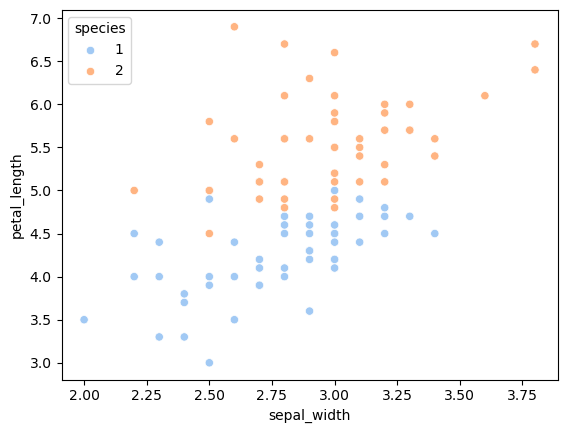

In [11]:
sns.scatterplot(data=df, x='sepal_width', y='petal_length', hue='species', palette='pastel');

# Shuffle the dataset and create train, val and test datasets

- Basically bootstrapping the data

In [12]:
df = df.sample(100) # Shuffle the dataset
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [13]:
df_train

,sepal_width,petal_length,species
74,2.9,4.3,1
149,3.0,5.1,2
138,3.0,4.8,2
147,3.0,5.2,2
67,2.7,4.1,1
53,2.3,4.0,1
125,3.2,6.0,2
79,2.6,3.5,1
130,2.8,6.1,2
126,2.8,4.8,2


In [14]:
df_val

,sepal_width,petal_length,species
87,2.3,4.4,1
99,2.8,4.1,1
127,3.0,4.9,2
97,2.9,4.3,1
146,2.5,5.0,2


In [15]:
df_test

,sepal_width,petal_length,species
139,3.1,5.4,2
117,3.8,6.7,2
112,3.0,5.5,2
144,3.3,5.7,2
122,2.8,6.7,2


# Train test split

In [16]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

# Bagging

## Part I - Bootstrapping and Training

In [17]:
# Helper function
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

### Tree 1

In [18]:
# Data for Tree 1 
df_bag1 = df_train.sample(8, replace=True) # Sampling with replacement (row can repeat)

X1 = df_bag1.iloc[:, 0:2]
y1 = df_bag1.iloc[:, -1]

In [19]:
df_bag1

,sepal_width,petal_length,species
125,3.2,6.0,2
138,3.0,4.8,2
149,3.0,5.1,2
147,3.0,5.2,2
130,2.8,6.1,2
74,2.9,4.3,1
74,2.9,4.3,1
149,3.0,5.1,2


In [20]:
dt_bag1 = DecisionTreeClassifier()

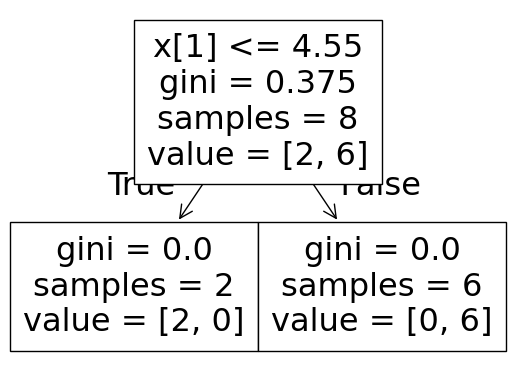

1.0


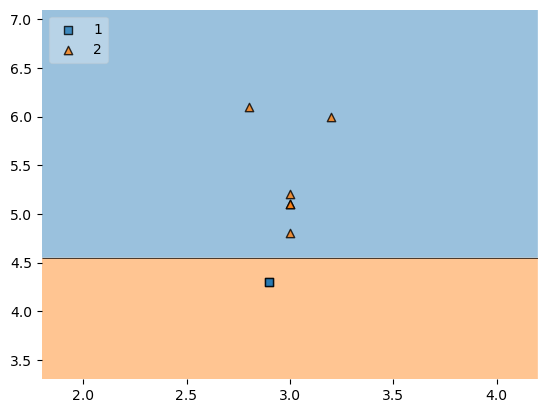

In [21]:
evaluate(dt_bag1, X1, y1)

### Tree 2

In [22]:
# Data for Tree 2 
df_bag2 = df_train.sample(8, replace=True) # Sampling with replacement (row can repeat)

X2 = df_bag2.iloc[:, 0:2]
y2 = df_bag2.iloc[:, -1]

In [23]:
df_bag2

,sepal_width,petal_length,species
125,3.2,6.0,2
147,3.0,5.2,2
79,2.6,3.5,1
67,2.7,4.1,1
79,2.6,3.5,1
79,2.6,3.5,1
67,2.7,4.1,1
130,2.8,6.1,2


In [24]:
dt_bag2 = DecisionTreeClassifier()

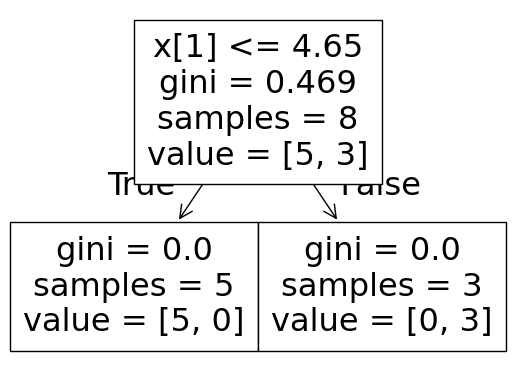

1.0


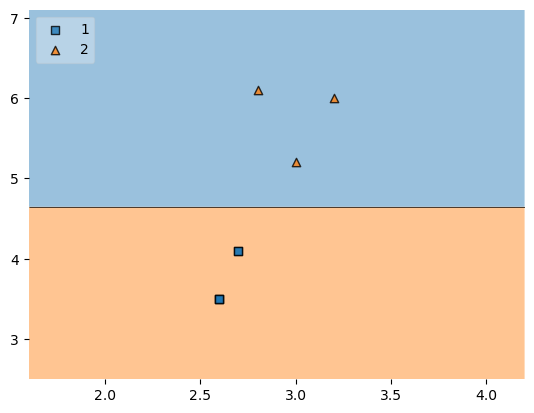

In [25]:
evaluate(dt_bag2, X2, y2)

### Tree 3

In [26]:
# Data for Tree 3 
df_bag3 = df_train.sample(8, replace=True) # Sampling with replacement (row can repeat)

X3 = df_bag3.iloc[:, 0:2]
y3 = df_bag3.iloc[:, -1]

In [27]:
df_bag3

,sepal_width,petal_length,species
74,2.9,4.3,1
74,2.9,4.3,1
74,2.9,4.3,1
67,2.7,4.1,1
126,2.8,4.8,2
125,3.2,6.0,2
147,3.0,5.2,2
74,2.9,4.3,1


In [28]:
dt_bag3 = DecisionTreeClassifier()

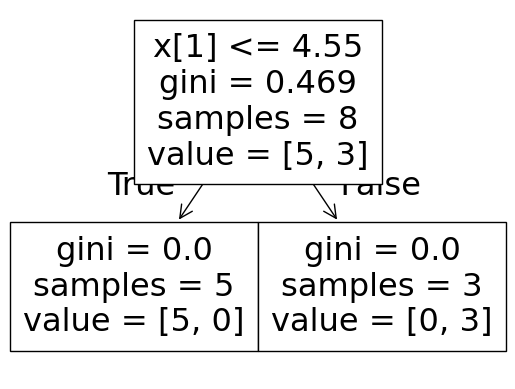

1.0


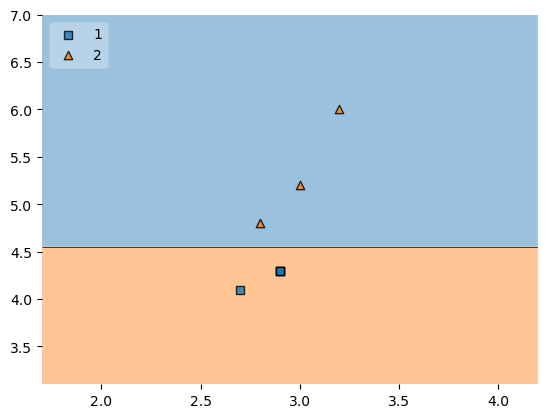

In [29]:
evaluate(dt_bag3, X3, y3)

## Part II - Aggregation (Prediction)

In [30]:
df_test

,sepal_width,petal_length,species
139,3.1,5.4,2
117,3.8,6.7,2
112,3.0,5.5,2
144,3.3,5.7,2
122,2.8,6.7,2


In [31]:
print("Predictor 1: ", dt_bag1.predict(np.array([2.8, 5.6]).reshape(1, 2)))
print("Predictor 2: ", dt_bag2.predict(np.array([2.8, 5.6]).reshape(1, 2)))
print("Predictor 3: ", dt_bag3.predict(np.array([2.8, 5.6]).reshape(1, 2)))

Predictor 1:  [2]
Predictor 2:  [2]
Predictor 3:  [2]
